In [12]:
import json
import networkx as nx
# import matplotlib as plt

In [ ]:
with open('./saved_tracks/slalom.json') as file:
    system = json.load(file)

In [14]:
G = nx.Graph()
nodes = {}
edges: list = []
pos = {}

In [15]:
for segment_id, segment in system["segments"].items():
    segment_type = segment["type"]
    ports = segment["connections"]

    for port, target in ports.items():
        own_port = f"{segment_id}.{port}"
        other_port = target

        print(own_port,other_port)
        if not target:
            node_id = f"{own_port}_end"
        elif(
            own_port.split(".")[0] <
            other_port.split(".")[0]
        ):
            node_id = f"{own_port}_{other_port}"
        else:
            node_id = f"{other_port}_{own_port}"

        if node_id not in nodes:
            nodes[node_id] = node_id
            print(segment)
            pos[node_id] = segment["location"][port]

        ports[port] = node_id

    # print(ports)

    if segment_type in ("st", "cl", "cr"):
        tuple = (ports["a"], ports["b"])
        # print(tuple)
        edges.append((ports["a"], ports["b"]))
    elif segment_type in ("sl", "sr"):
        edges.append((ports["a"], ports["b"]))
        if "c" in ports and ports["c"] is not None:
            edges.append((ports["a"], ports["c"]))
    else:
        print("segment type not found")

7e5e66e0-9267-4f7a-8c88-82a28baa69d9.a None
{'type': 'st', 'connections': {'a': None, 'b': 'a831bc24-131f-4864-95f4-3636f0c4bebc.a'}, 'location': {'a': [0.0, -0.0], 'b': [200.0, 0.0]}, 'metadata': {'starting_end': 'a', 'length': 200, 'coords': [0, 0, 90]}}
7e5e66e0-9267-4f7a-8c88-82a28baa69d9.b a831bc24-131f-4864-95f4-3636f0c4bebc.a
{'type': 'st', 'connections': {'a': '7e5e66e0-9267-4f7a-8c88-82a28baa69d9.a_end', 'b': 'a831bc24-131f-4864-95f4-3636f0c4bebc.a'}, 'location': {'a': [0.0, -0.0], 'b': [200.0, 0.0]}, 'metadata': {'starting_end': 'a', 'length': 200, 'coords': [0, 0, 90]}}
a831bc24-131f-4864-95f4-3636f0c4bebc.a 7e5e66e0-9267-4f7a-8c88-82a28baa69d9.b
a831bc24-131f-4864-95f4-3636f0c4bebc.b acf9576d-79b1-443d-8f58-cb6fc528c137.a
{'type': 'st', 'connections': {'a': '7e5e66e0-9267-4f7a-8c88-82a28baa69d9.b_a831bc24-131f-4864-95f4-3636f0c4bebc.a', 'b': 'acf9576d-79b1-443d-8f58-cb6fc528c137.a'}, 'location': {'a': [200.0, -0.0], 'b': [400.0, 0.0]}, 'metadata': {'starting_end': 'a', 'len

In [16]:
len(nodes)

39

In [17]:
len(pos)

39

In [18]:
pos

{'7e5e66e0-9267-4f7a-8c88-82a28baa69d9.a_end': [0.0, -0.0],
 '7e5e66e0-9267-4f7a-8c88-82a28baa69d9.b_a831bc24-131f-4864-95f4-3636f0c4bebc.a': [200.0,
  0.0],
 'a831bc24-131f-4864-95f4-3636f0c4bebc.b_acf9576d-79b1-443d-8f58-cb6fc528c137.a': [400.0,
  0.0],
 'acf9576d-79b1-443d-8f58-cb6fc528c137.b_d9d4a3ec-2a09-43c1-ace3-8f287a364a42.a': [600.0,
  0.0],
 '13d14759-9c99-48d1-b13f-8ffee5eb140b.a_d9d4a3ec-2a09-43c1-ace3-8f287a364a42.b': [800.0,
  -0.0],
 'ba42f15d-1e4c-4f6d-846b-d0ee5e1c5a35.c_d9d4a3ec-2a09-43c1-ace3-8f287a364a42.c': [800.0,
  53.59],
 '13d14759-9c99-48d1-b13f-8ffee5eb140b.b_3399e377-806a-4bd2-b49b-87a62768dfaf.b': [1000.0,
  -0.0],
 '3399e377-806a-4bd2-b49b-87a62768dfaf.a_eb1959d5-21f3-4d18-a96f-08c4b82f582a.b': [1200.0,
  0.0],
 '3399e377-806a-4bd2-b49b-87a62768dfaf.c_76d850e8-6428-456e-9629-695e75165211.c': [1000.0,
  -53.59],
 '8112bedb-10d7-4a20-9dd1-637a4857cc3d.a_916d4ef9-f290-4e8c-a895-e70401ebe56f.b': [1600.0,
  -0.0],
 '8112bedb-10d7-4a20-9dd1-637a4857cc3d.b_end':

In [19]:
G.add_edges_from(edges)

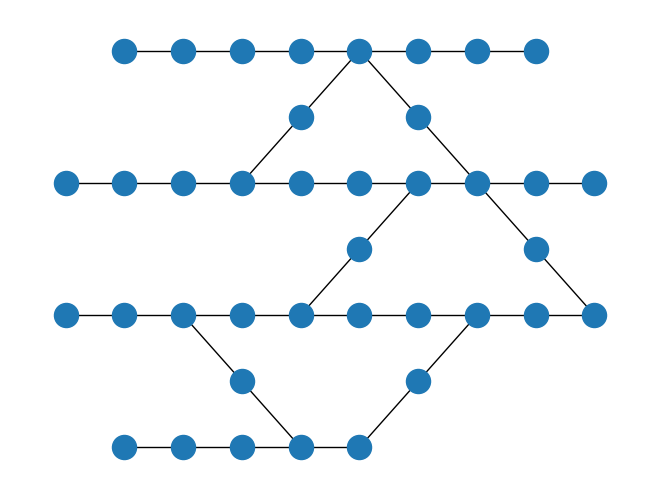

In [20]:
# pos = nx.spring_layout(G)

# for key, coords  in pos.items():
#     pos[key] = coords[::-1]


nx.draw(G, pos, with_labels=False)
# print(pos, pos2)


In [21]:
path = nx.shortest_path(G, source="3.b_4.b", target="20.a_end")

NodeNotFound: Source 3.b_4.b is not in G

In [ ]:
path